
# Objetivo del Script
Visualizar los **precios promedio por metro cuadrado** en colonias de la **Ciudad de México y el Estado de México** mediante mapas de calor utilizando datos geoespaciales.

## Resumen del flujo
1. Cargar datos de precios y shapefile.
2. Limpiar y normalizar nombres de colonias y municipios.
3. Corregir inconsistencias de texto.
4. Fusionar datos geográficos con precios.
5. Filtrar regiones de interés.
6. Generar mapas de calor.
7. Exportar mapas como imágenes.

---

# Archivos de Entrada
- `/content/df_merged.csv` → datos de precios por colonia  
- `/content/Colonias.shp` → geometrías de colonias

# Archivos de Salida
- `precio_metro_cuadrado_cdmx.jpeg`
- `precio_metro_cuadrado_edomex.jpeg`
- `precio_metro_cuadrado_cdmx_edomex.jpeg`

---

# Librerías Utilizadas
- **pandas** → manipulación de datos  
- **geopandas** → manejo de datos geoespaciales  
- **matplotlib** → visualización de mapas  
- **re** → normalización de texto con expresiones regulares

---

# 1. Carga y preprocesamiento de datos

**Acciones**
- Cargar el CSV con precios.
- Convertir `Colonia`, `Municipio` y `Estado` a mayúsculas.
- Eliminar espacios y duplicados.
- Filtrar precios extremos.

**Puntos clave**
- Se excluyen valores `> 130000` por m².
- Se carga el shapefile con las geometrías de colonias.

---

# 2. Separación por entidad

Se crean subconjuntos de datos:

- **CDMX**
- **Estado de México**

**Punto clave**

Permite aplicar limpieza y análisis específicos por región.

---

# 3. Limpieza adicional para Edo. de México

**Acciones**
- Ordenar precios de mayor a menor.
- Eliminar algunos valores extremos.

**Punto clave**

Reduce el impacto de **outliers** en la escala del mapa.

---

# 4. Normalización de nombres

Se estandarizan nombres de colonias y municipios entre:

- `df_precios`
- `df_map`

**Acciones**
- Mayúsculas y eliminación de espacios.
- Corrección de acentos en municipios.
- Normalización de abreviaciones (`SECCION → SECC`, `1RA → 1A`, etc.).

**Punto clave**

Mejora la correspondencia entre el dataset y el shapefile.

---

# 5. Correcciones específicas

Se ajustan casos particulares de colonias y asentamientos.

**Ejemplos**
- Unificación de variantes de **POLANCO**.
- Normalización de **SAN JUAN DE ARAGON**.
- Correcciones con **expresiones regulares**.

**Punto clave**

Evita errores en la unión geográfica de los datos.

---

# 6. Fusión de datos

Se integran los precios con las geometrías.

```python
df_map.merge(
    df_precios_subset,
    left_on=["SETT_NAME", "MUN_NAME"],
    right_on=["Colonia", "Municipio"]
)
````

**Puntos clave**

* Unión tipo **left join**.
* Las colonias sin datos mantienen su geometría.

---

# 7. Filtrado geográfico

Se crean subconjuntos para:

* **CDMX**
* **Municipios metropolitanos del Edo. de México**

**Punto clave**

Se limita el análisis a municipios relevantes del área metropolitana.

---

# 8. Generación de mapas de calor

Se generan tres visualizaciones:

### CDMX

* Colonias sin datos → **gris**
* Colonias con datos → **escala `jet`**

### Estado de México

* Solo se muestran colonias con datos de precio.

### Mapa combinado

* Integra CDMX + municipios seleccionados del Edo. de México.
* Se dibuja el **contorno de la CDMX** para referencia.


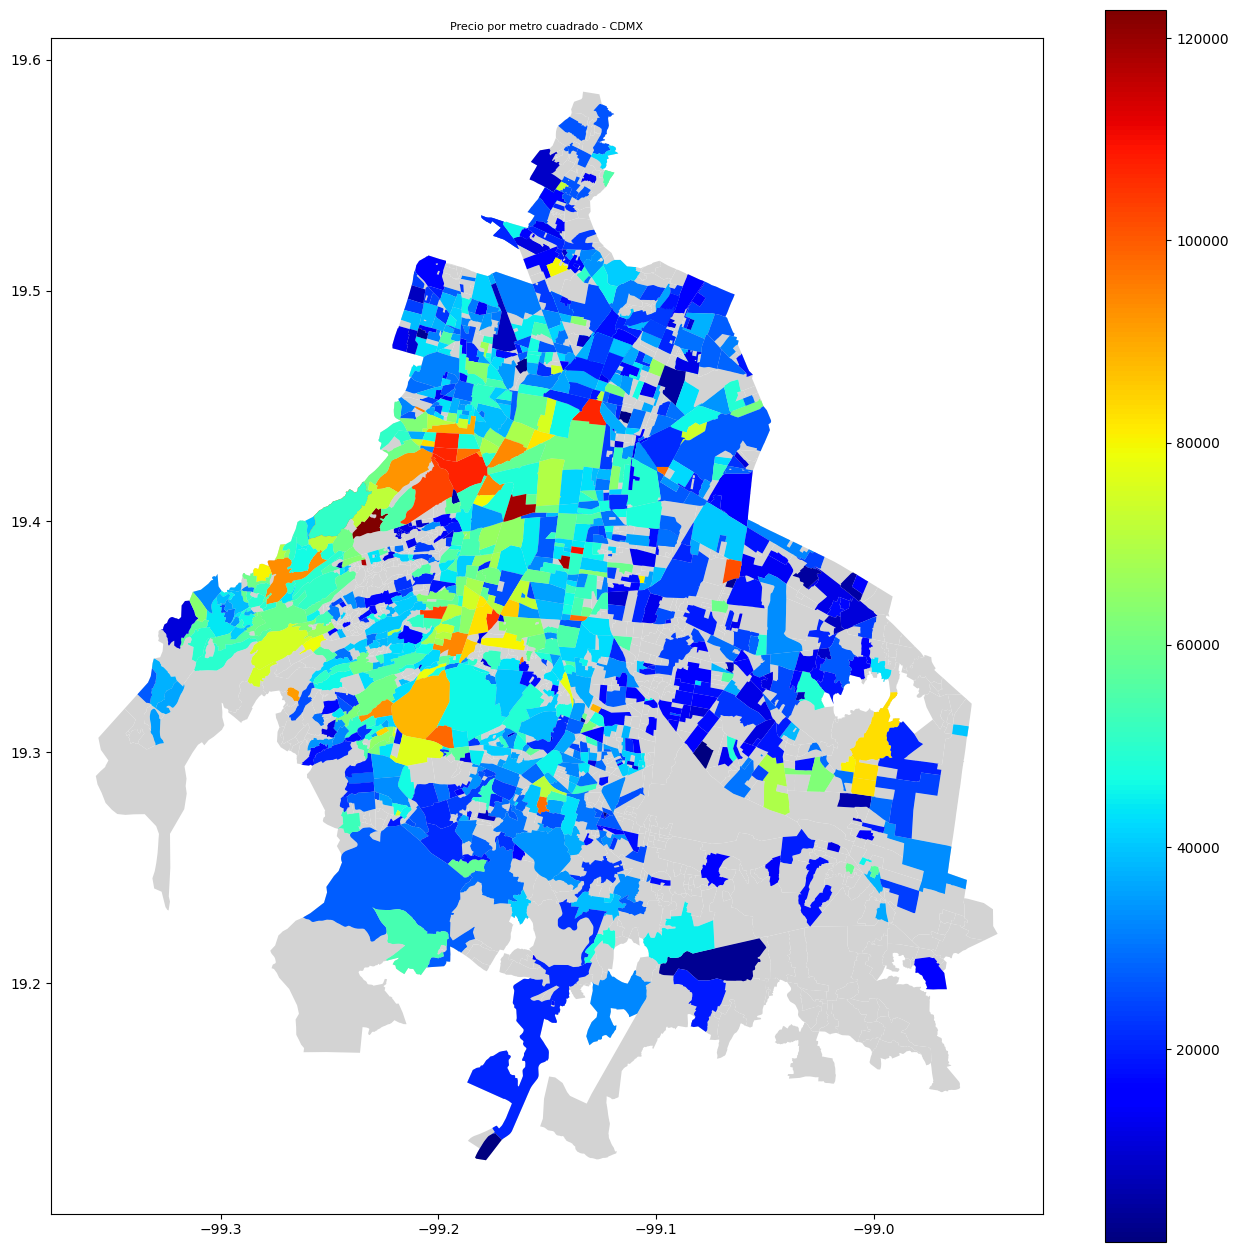

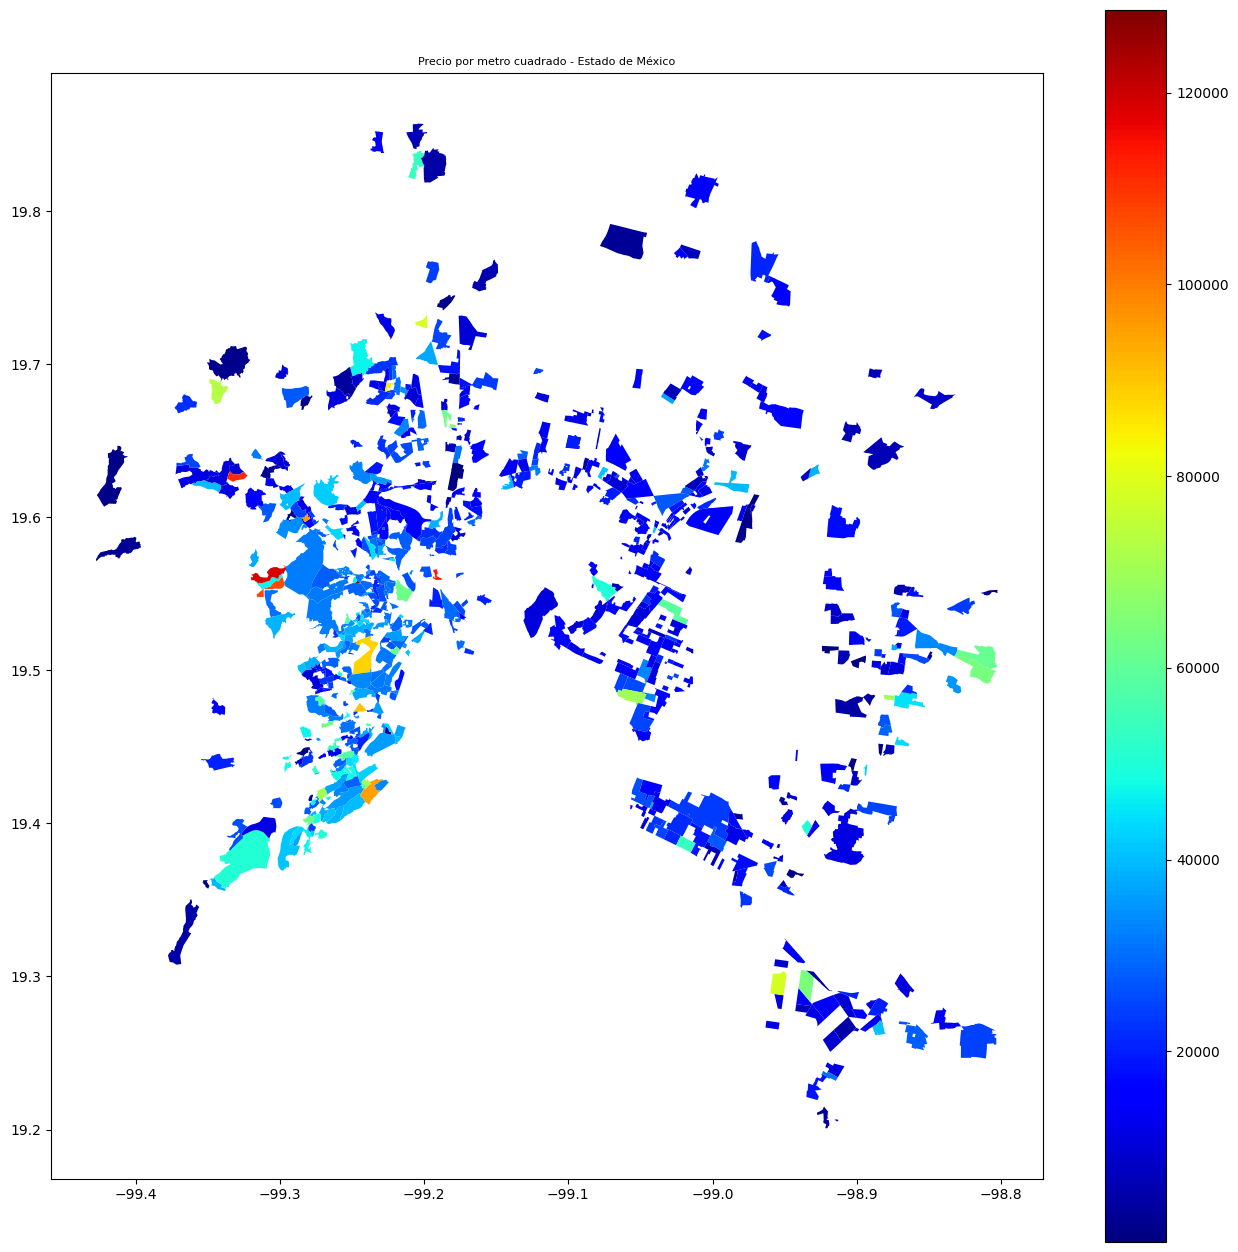

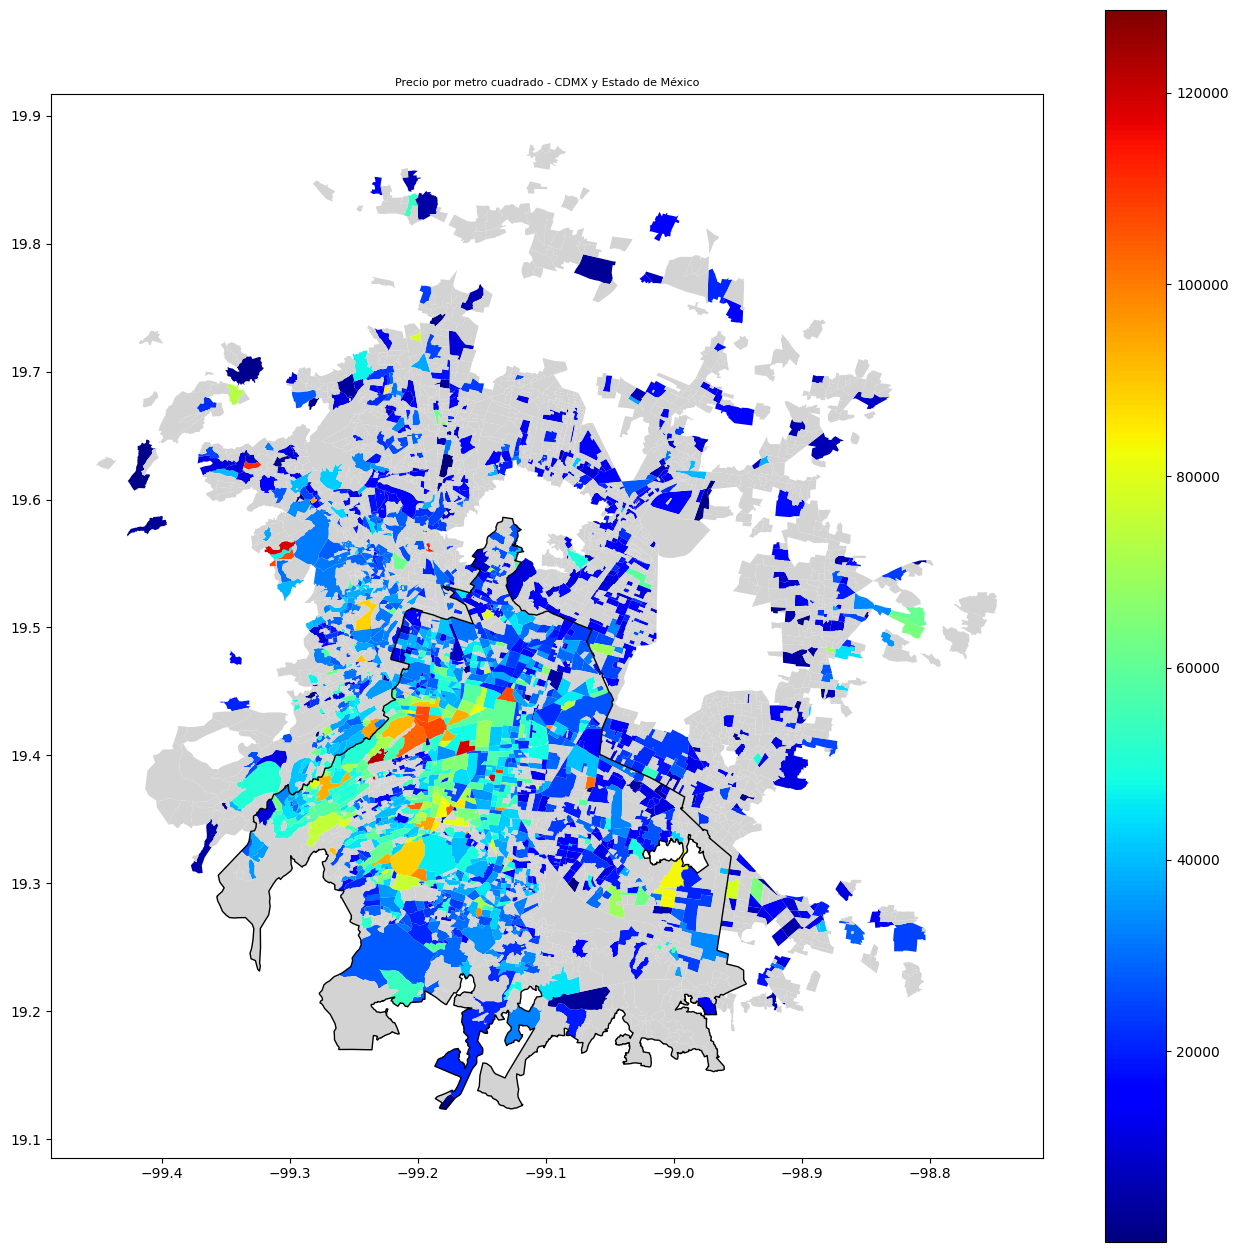

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import re

# --- Carga y preprocesamiento inicial de datos ---
# Cargar datos de precios de venta desde un archivo CSV
df_precios = pd.read_csv('/content/df_merged.csv')

# Normalizar las columnas de texto para facilitar la correspondencia (upper case, strip whitespace)
df_precios["Colonia"] = df_precios["Colonia"].str.upper().str.strip()
df_precios["Municipio"] = df_precios["Municipio"].str.upper().str.strip()
df_precios["Estado"] = df_precios["Estado"].str.upper().str.strip()

# Filtrar valores atípicos y eliminar duplicados en los datos de precios
df_precios = df_precios[df_precios['valor_m2_promedio_venta'] < 130000].copy()
df_precios.drop_duplicates(subset=['Colonia', 'Municipio', 'Estado'], keep='first', inplace=True)

# Cargar el archivo shapefile de colonias (datos geográficos)
df_map = gpd.read_file("/content/Colonias.shp")

# Filtrar datos de precios por estado (Ciudad de México y Estado de México)
df_precios_cdmx = df_precios[df_precios['Estado'] == 'Ciudad de Mexico'].copy()
df_precios_edomex = df_precios[df_precios['Estado'] == 'Estado de Mexico'].copy()

# Manejo específico para el Estado de México: remover valores extremos y ordenar
if not df_precios_edomex.empty:
    df_precios_edomex = df_precios_edomex.sort_values(by='valor_m2_promedio_venta', ascending=False)
    df_precios_edomex = df_precios_edomex.iloc[11:].copy()
    df_precios_edomex = df_precios_edomex[~df_precios_edomex.index.isin([3, 4, 5])].reset_index(drop=True)

# --- Normalización de nombres para el mapeo geográfico ---
# Normalizar nombres de colonias y municipios en ambos dataframes para unificar criterios
df_precios["Colonia"] = df_precios["Colonia"].str.upper().str.strip()
df_precios["Municipio"] = df_precios["Municipio"].str.upper().str.strip()
df_map["SETT_NAME"] = df_map["SETT_NAME"].str.upper().str.strip()
df_map["MUN_NAME"] = df_map["MUN_NAME"].str.upper().str.strip()

# Corregir acentos y variaciones en nombres de municipios de df_precios (CDMX)
df_precios['Municipio'] = df_precios['Municipio'].replace('ALVARO OBREGON', 'ÁLVARO OBREGÓN')
df_precios['Municipio'] = df_precios['Municipio'].replace('BENITO JUAREZ', 'BENITO JUÁREZ')
df_precios['Municipio'] = df_precios['Municipio'].replace('COYOACAN', 'COYOACÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('CUAUHTEMOC', 'CUAUHTÉMOC')
df_precios['Municipio'] = df_precios['Municipio'].replace('TLAHUAC', 'TLÁHUAC')
df_precios['Municipio'] = df_precios['Municipio'].replace('GUSTAVO A. MADERO', 'GUSTAVO A MADERO')

# Corregir acentos y variaciones en nombres de municipios de df_precios (Estado de México)
df_precios['Municipio'] = df_precios['Municipio'].replace('ALMOLOYA DE JUAREZ', 'ALMOLOYA DE JUÁREZ')
df_precios['Municipio'] = df_precios['Municipio'].replace('ALMOLOYA DEL RIO', 'ALMOLOYA DEL RÍO')
df_precios['Municipio'] = df_precios['Municipio'].replace('ATIZAPAN', 'ATIZAPÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('ATIZAPAN DE ZARAGOZA', 'ATIZAPÁN DE ZARAGOZA')
df_precios['Municipio'] = df_precios['Municipio'].replace('CHIMALHUACAN', 'CHIMALHUACÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('COACALCO DE BERRIOZABAL', 'COACALCO DE BERRIOZÁBAL')
df_precios['Municipio'] = df_precios['Municipio'].replace('COCOTITLAN', 'COCOTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('CUAUTITLAN', 'CUAUTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('CUAUTITLAN IZCALLI', 'CUAUTITLÁN IZCALLI')
df_precios['Municipio'] = df_precios['Municipio'].replace('JOCOTITLAN', 'JOCOTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('NAUCALPAN DE JUAREZ', 'NAUCALPAN DE JUÁREZ')
df_precios['Municipio'] = df_precios['Municipio'].replace('NEZAHUALCOYOTL', 'NEZAHUALCÓYOTL')
df_precios['Municipio'] = df_precios['Municipio'].replace('NICOLAS ROMERO', 'NICOLÁS ROMERO')
df_precios['Municipio'] = df_precios['Municipio'].replace('POLOTITLAN', 'POLOTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('RAYON', 'RAYÓN')
df_precios['Municipio'] = df_precios['Municipio'].replace('SAN JOSE DEL RINCON', 'SAN JOSÉ DEL RINCÓN')
df_precios['Municipio'] = df_precios['Municipio'].replace('SAN MARTIN DE LAS PIRAMIDES', 'SAN MARTÍN DE LAS PIRÁMIDES')
df_precios['Municipio'] = df_precios['Municipio'].replace('SAN SIMON DE GUERRERO', 'SAN SIMÓN DE GUERRERO')
df_precios['Municipio'] = df_precios['Municipio'].replace('SANTO TOMAS', 'SANTO TOMÁS')
df_precios['Municipio'] = df_precios['Municipio'].replace('SOYANIQUILPAN DE JUAREZ', 'SOYANIQUILPAN DE JUÁREZ')
df_precios['Municipio'] = df_precios['Municipio'].replace('TECAMAC', 'TECÁMAC')
df_precios['Municipio'] = df_precios['Municipio'].replace('TEOTIHUACAN', 'TEOTIHUACÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('TEPOTZOTLAN', 'TEPOTZOTLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('TEXCALTITLAN', 'TEXCALTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('TULTITLAN', 'TULTITLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('VILLA DEL CARBON', 'VILLA DEL CARBÓN')
df_precios['Municipio'] = df_precios['Municipio'].replace('XONACATLAN', 'XONACATLÁN')
df_precios['Municipio'] = df_precios['Municipio'].replace('ZUMPAHUACAN', 'ZUMPAHUACÁN')

# Limpieza y normalización de nombres de asentamientos en df_map
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('SECCION', 'SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('1RA', '1A')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('2DA', '2A')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('3RA', '3A')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('POLANCO REFORMA', 'POLANCO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('POLANCO CHAPULTEPEC', 'POLANCO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('BOSQUES', 'BOSQUE')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('SELENE 1A SECC', 'SELENE')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('SELENE 2A SECC', 'SELENE')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNIDAD HAB SANTA CRUZ MEYEHUALCO', 'SANTA CRUZ MEYEHUALCO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('PUEBLO SANTA CRUZ MEYEHUALCO', 'SANTA CRUZ MEYEHUALCO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNIDAD HAB BELEN', 'BELEN DE LAS FLORES')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('PRESIDENTES', '2A AMPL PRESIDENTES')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('AMPL PRESIDENTES', '2A AMPL PRESIDENTES')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('SAN CARLOS CANTERA', 'SAN CARLOS')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('FRACC SAN CARLOS', 'SAN CARLOS')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNIDAD HAB SAN CARLOS', 'SAN CARLOS')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('LOMAS DE SAN CARLOS', 'SAN CARLOS')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('INDUSTRIAL CERRO GORDO', 'JARDINES DE CERRO GORDO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('CERRO GORDO', 'JARDINES DE CERRO GORDO')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNID HAB HEROES ECATEPEC 1 2 3 4 T', 'LOS HEROES DE ECATEPEC 1A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('HEROES ECATEPEC 5TA SECC', 'LOS HEROES DE ECATEPEC 1A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('EJIDO DE SAN CRISTOBAL', 'SAN CRISTOBAL')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('FRACC JARDINES DE LOS CLAUSTROS V', 'JARDINES DE LOS CLAUSTROS VI')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('FRACC JARDINES DE LOS CLAUSTROS IV', 'JARDINES DE LOS CLAUSTROS VI')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('VILLA DE LAS FLORES 1A SECC', 'VILLA DE LAS FLORES 1A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('VILLA DE LAS FLORES', 'VILLA DE LAS FLORES 1A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('LA PRESITA SAN MARTIN TEPETLIXPAN', 'SAN MARTIN TEPETLIXPA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('EJIDO SAN MARTIN TEPETLIXPAN', 'SAN MARTIN TEPETLIXPA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNIDAD HAB SAN MARTIN', 'SAN MARTIN TEPETLIXPA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('JARDINES DE LA HACIENDA 1A SECC', 'JARDINES DE LA HACIENDA NORTE')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('BOSQUE DE LA HACIENDA 1A SECC', 'BOSQUE DE LA HACIENDA 1A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('BOSQUE DE LA HACIENDA 2A SECC', 'BOSQUE DE LA HACIENDA 3A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('BOSQUE DE LA HACIENDA 3A SECC', 'BOSQUE DE LA HACIENDA 3A SECC')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('SECC PARQUES', 'CUAUTITLAN IZCALLI SECC PARQUES')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('LOS REYES', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('LOS REYES IXTACALA', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('JARDINES DE LOS REYES', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('LOS REYES IXTACALA 2A SECC', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('UNIDAD HAB GUSTAVO BAZ PRADA LOS REYES IXTACALA', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('FRACC LOS REYES IXTACALA 1A SECC', 'LOS REYES IXTACALA')
df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('ZONA INDUSTRIAL LOS REYES', 'LOS REYES IXTACALA')


df_map['SETT_NAME'] = df_map['SETT_NAME'].str.replace('.', '', regex=False)
df_map['SETT_NAME'] = df_map['SETT_NAME'].apply(lambda x: re.sub(r'BELEN DE LAS FLORES.*', 'BELEN DE LAS FLORES', x))
df_map['SETT_NAME'] = df_map['SETT_NAME'].apply(lambda x: re.sub(r'MAGDALENA MIXHUCA.*', 'MAGDALENA MIXHUCA', x))

# Corrección específica para 'CUAUTEPEC' en df_map
condition = (df_map['SETT_NAME'].str.contains('CUAUTEPEC')) & (df_map['MUN_NAME'] == 'GUSTAVO A MADERO')
df_map.loc[condition, 'SETT_NAME'] = 'CUAUTEPEC DE MADERO'

# Limpieza y normalización de nombres de colonias en df_precios
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SECCION', 'SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('1RA', '1A')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('2DA', '2A')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('3RA', '3A')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('EX-', 'EX ')
df_precios['Colonia'] = df_precios['Colonia'].str.replace(' - ', ' ')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('.', '', regex=False)
df_precios['Colonia'] = df_precios['Colonia'].str.replace('BOSQUES', 'BOSQUE')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('CENTRAL DE ABASTO', 'CENTRAL DE ABASTOS')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('UNIDAD HAB BELEN', 'BELEN DE LAS FLORES')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON I SECC', 'SAN JUAN DE ARAGON 1A SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON II SECC', 'SAN JUAN DE ARAGON 2A SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('FERNANDO CASAS ALEMAN', 'CASAS ALEMAN')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('CENTRO URBANO PRESIDENTE ALEMAN', 'MIGUEL ALEMAN')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SANTA FE IMSS', 'UNIDAD HAB SANTA FE IMSS')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('LOMAS DE LOS ANGELES DEL PUEBLO TETELPAN     ', 'LOMAS DE LOS ANGELES TETELPAN')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('LAS AGUILAS 1A SECC', 'PARQUE LAS AGUILAS')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('LAS AGUILAS 2O PARQUE', 'LAS AGUILAS AMPLIACION 2O PARQUE')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('LAS AGUILAS 3ER PARQUE', 'AMPL LAS AGUILAS 3ER PARQUE')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('AMPLIACION SELENE', 'AMPL SELENE')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('EL PIRU SANTA FE', 'DESARROLLO URBANO EL PIRU')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('LOMAS DE BECERRA', 'LOMAS DE BECERRA GRANADA')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('DANIEL GARZA', 'AMPL DANIEL GARZA')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON I SECC', 'EJIDOS SAN JUAN DE ARAGON 1A SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON II SECC', 'SAN JUAN DE ARAGON EJIDOS 2A SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON III SECC', 'SAN JUAN DE ARAGON 3A SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON IV SECC', 'SAN JUAN DE ARAGON 4TA Y 5TA SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON VI SECC', 'SAN JUAN DE ARAGON 6TA SECC')
df_precios['Colonia'] = df_precios['Colonia'].str.replace('SAN JUAN DE ARAGON VII SECC', 'SAN JUAN DE ARAGON 7MA SECC')

# Corrección específica para 'NIÑOS HEROES' en df_precios
df_precios.loc[
    (df_precios['Colonia'] == 'NIÑOS HEROES') & (df_precios['Municipio'] == 'BENITO JUÁREZ'),
    'Colonia'
] = 'NIÑOS HEROES DE CHAPULTEPEC'

# --- Fusión de datos y preparación para el mapeo ---
# Seleccionar columnas relevantes de df_precios
df_precios_subset = df_precios[['Colonia', 'Municipio', 'valor_m2_promedio_venta']].copy()

# Fusionar df_map con df_precios_subset usando 'SETT_NAME'/'Colonia' y 'MUN_NAME'/'Municipio'
df_map = df_map.merge(
    df_precios_subset,
    how="left",
    left_on=["SETT_NAME", "MUN_NAME"],
    right_on=["Colonia", "Municipio"]
)

# Renombrar la columna de precios para mayor claridad
df_map = df_map.rename(columns={"valor_m2_promedio_venta": "precio_m2"})

# Separar el dataframe fusionado en CDMX y Estado de México
df_map_cdmx = df_map[df_map["ST_NAME"] == "DISTRITO FEDERAL"].copy()
df_map_edo = df_map[df_map["ST_NAME"] == "MEXICO"].copy()

# Definir una lista de municipios relevantes del Estado de México
edo_municipalities = [
    'ACOLMAN',
    'ATENCO',
    'ATIZAPÁN DE ZARAGOZA',
    'CHALCO',
    'CHIAUTLA',
    'CHICOLOAPAN',
    'CHIMALHUACÁN',
    'COACALCO DE BERRIOZÁBAL',
    'CUAUTITLÁN',
    'CUAUTITLÁN IZCALLI',
    'ECATEPEC DE MORELOS',
    'HUEHUETOCA',
    'HUIXQUILUCAN',
    'LA PAZ',
    'NAUCALPAN DE JUÁREZ',
    'NEZAHUALCÓYOTL',
    'NICOLÁS ROMERO',
    'TECÁMAC',
    'TEOLOYUCAN',
    'TEOTIHUACÁN',
    'TEPOTZOTLÁN',
    'TEXCOCO',
    'TEZOYUCA',
    'TLALNEPANTLA DE BAZ',
    'TONANITLA',
    'TULTEPEC',
    'TULTITLÁN',
    'VALLE DE CHALCO SOLIDARIDAD',
    'ZUMPANGO'
]
# Filtrar df_map_edo para incluir solo los municipios definidos
df_map_edo = df_map_edo[df_map_edo['MUN_NAME'].isin(edo_municipalities)].copy()

# --- Visualización de mapas de calor de precios ---

# Crear un mapa para la CDMX
fig, ax = plt.subplots(1, figsize=(16, 16))
df_map_cdmx.plot(ax=ax, color='lightgrey') # Dibujar las áreas sin datos de precios en gris claro
df_map_cdmx.plot(column="precio_m2", cmap="jet", legend=True, ax=ax) # Dibujar el mapa de calor de precios

# Resaltar con un margen rojo las colonias 'LA CIENEGA CHICA' y 'PARQUE ECOLOGICO DE XOCHIMILCO' en Xochimilco
# cienega_chica_outline = df_map_cdmx[(df_map_cdmx['MUN_NAME'] == 'XOCHIMILCO') & (df_map_cdmx['SETT_NAME'] == 'LA CIENEGA CHICA')]
# if not cienega_chica_outline.empty:
#     cienega_chica_outline.geometry.boundary.plot(ax=ax, color='red', linewidth=2)

# parque_ecologico_outline = df_map_cdmx[(df_map_cdmx['MUN_NAME'] == 'XOCHIMILCO') & (df_map_cdmx['SETT_NAME'] == 'PARQUE ECOLOGICO DE XOCHIMILCO')]
# if not parque_ecologico_outline.empty:
#     parque_ecologico_outline.geometry.boundary.plot(ax=ax, color='red', linewidth=2)

# Configurar título y guardar el mapa de CDMX
plt.title("Precio por metro cuadrado - CDMX", fontsize=8)
plt.savefig("precio_metro_cuadrado_cdmx.jpeg", dpi=1000, bbox_inches="tight")
plt.show()

# Crear un mapa para el Estado de México
fig, ax = plt.subplots(1, figsize=(16, 16))
# Dibujar el mapa de calor de precios para el Edo. de México, excluyendo áreas sin datos
df_map_edo.dropna(subset=['precio_m2']).plot(column="precio_m2", cmap="jet", legend=True, ax=ax)
plt.title("Precio por metro cuadrado - Estado de México", fontsize=8)
plt.savefig("precio_metro_cuadrado_edomex.jpeg", dpi=1000, bbox_inches="tight")
plt.show()

# Crear un mapa combinado para CDMX y Estado de México
fig, ax = plt.subplots(1, figsize=(16, 16))

# Filtrar el dataframe combinado para incluir CDMX y los municipios específicos del Edo. de México
df_map_combined = df_map[
    (df_map['ST_NAME'] == 'DISTRITO FEDERAL') |
    ((df_map['ST_NAME'] == 'MEXICO') & (df_map['MUN_NAME'].isin(edo_municipalities)))
].copy()

# Dibujar el mapa de calor de precios para las áreas con datos
df_map_combined.dropna(subset=['precio_m2']).plot(column="precio_m2", cmap="jet", legend=True, ax=ax)
# Dibujar las áreas sin datos de precios en gris claro
df_map_combined[(df_map_combined['precio_m2'].isna())].plot(ax=ax, color='lightgrey')

# Obtener el contorno de la CDMX para dibujarlo sobre el mapa combinado
# Nota: Se usa 'union_all()' en lugar de 'unary_union' por deprecación
cdmx_outline = df_map_cdmx.geometry.union_all()

# Dibujar el contorno de la CDMX en negro
gpd.GeoSeries([cdmx_outline]).boundary.plot(ax=ax, color='black', linewidth=1)

# Configurar título y guardar el mapa combinado
plt.title("Precio por metro cuadrado - CDMX y Estado de México", fontsize=8)
plt.savefig("precio_metro_cuadrado_cdmx_edomex.jpeg", dpi=1000, bbox_inches="tight")
plt.show()

In [ ]:
# Crear un dataframe temporal con las claves de SETT_NAME y MUN_NAME de df_map
# para asegurar que solo se consideren las combinaciones únicas de asentamiento y municipio existentes en el mapa.
df_map_keys = df_map[['SETT_NAME', 'MUN_NAME']].drop_duplicates()

# Realizar un left merge de df_precios_subset con las claves de df_map.
# El parámetro 'indicator=True' añade una columna '_merge' que indica el origen de cada fila.
# 'left_only' significa que la fila existe solo en df_precios_subset y no encontró un match en df_map_keys.
unmatched_precios = df_precios_subset.merge(
    df_map_keys,
    left_on=["Colonia", "Municipio"],
    right_on=["SETT_NAME", "MUN_NAME"],
    how="left",
    indicator=True
)

# Filtrar las filas que no encontraron una coincidencia ('left_only')
df_precios_not_on_map = unmatched_precios[unmatched_precios['_merge'] == 'left_only'].copy()

# Seleccionar solo las columnas originales de df_precios_subset para el resultado final
df_precios_not_on_map = df_precios_not_on_map[['Colonia', 'Municipio', 'valor_m2_promedio_venta']]

print(f"Número de filas en df_precios_subset que no se encontraron en el mapa: {len(df_precios_not_on_map)}")
display(df_precios_not_on_map.head())

Número de filas en df_precios_subset que no se encontraron en el mapa: 1196


,Colonia,Municipio,valor_m2_promedio_venta
3,10 DE AGOSTO,IXTAPAN DE LA SAL,27500.000000
5,14 DE DICIEMBRE,ATIZAPÁN DE ZARAGOZA,25000.000000
9,1A DE MARZO,TENANCINGO,1640.000000
14,2A DEL MORAL DEL PUEBLO DE TETELPAN,ÁLVARO OBREGÓN,48441.948995
16,3 DE MAYO,NAUCALPAN DE JUÁREZ,26655.219780


# pruebas

Realizando búsqueda difusa para colonias no encontradas...


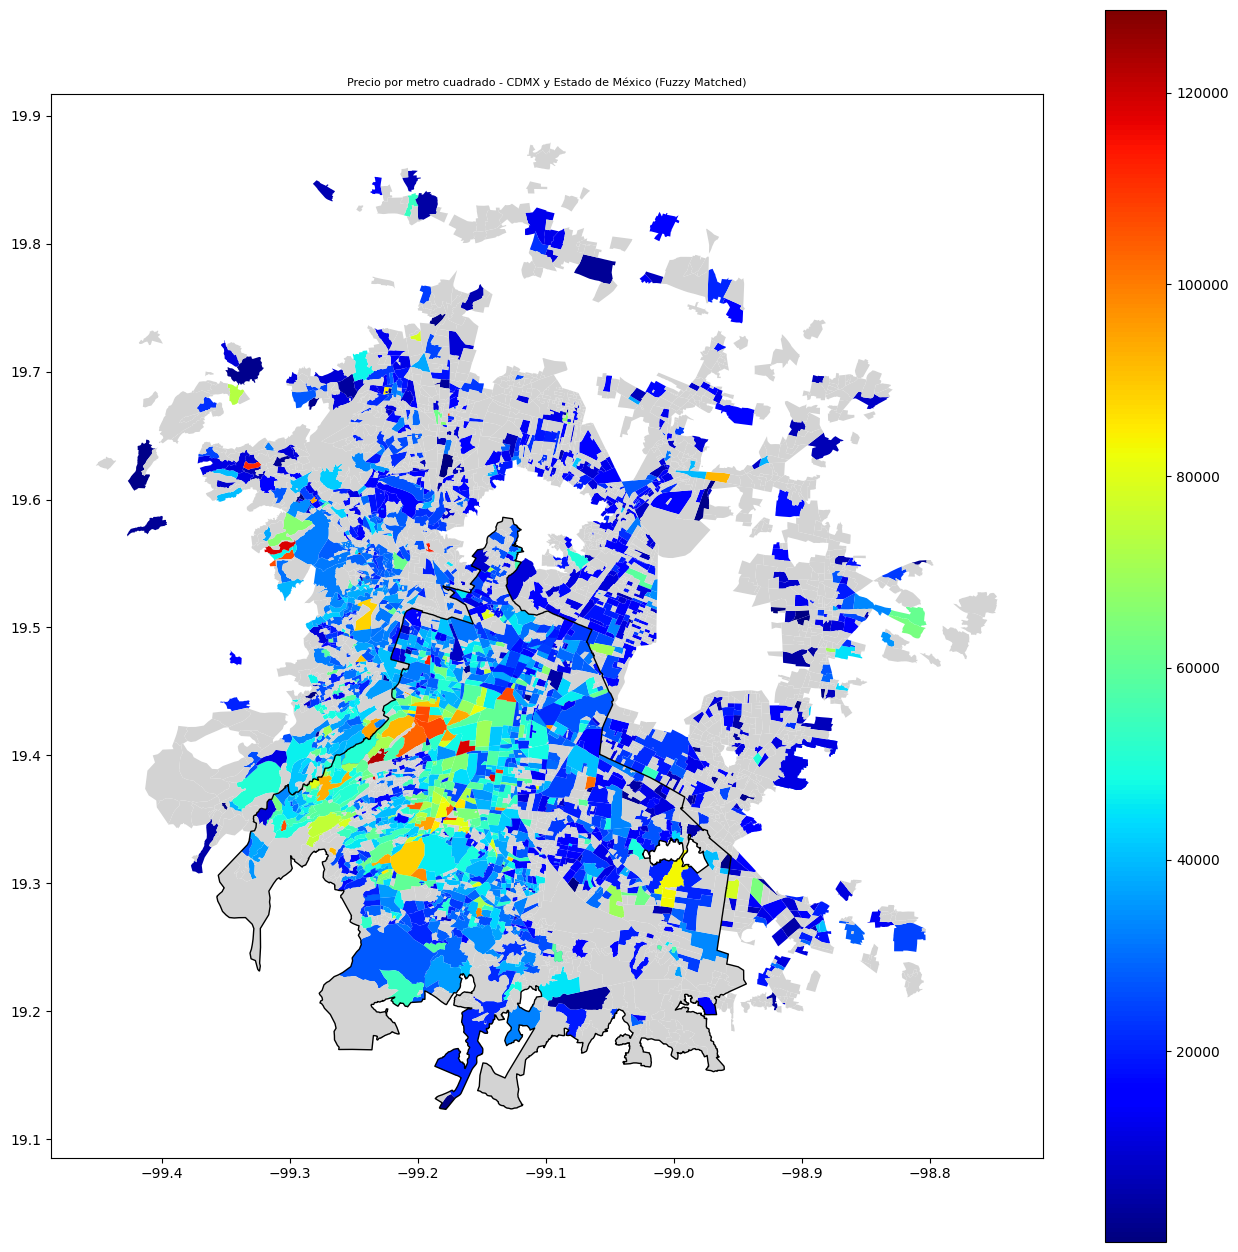

In [ ]:
import pandas as pd
import geopandas as gpd
from difflib import get_close_matches
import unicodedata
import matplotlib.pyplot as plt

def clean_text(text):
    if not isinstance(text, str): return ""
    # Quitar acentos y convertir a mayúsculas
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = text.upper().strip()
    # Eliminar palabras "ruido" que estorban en el match
    words_to_remove = [
        "COLONIA", "FRACCIONAMIENTO", "UNIDAD HABITACIONAL", "U H ", "PUEBLO",
        "BARRIO", "RESIDENCIAL", "AMPLIACION", "SECCION", "SECC", "FRACC"
    ]
    for word in words_to_remove:
        text = text.replace(word, "")
    # Quitar puntos y espacios múltiples
    text = text.replace(".", "").replace("  ", " ").strip()
    return text

# --- Aplicar limpieza base ---
df_precios["Colonia_Clean"] = df_precios["Colonia"].apply(clean_text)
df_precios["Muni_Clean"] = df_precios["Municipio"].apply(clean_text)

df_map["Colonia_Clean"] = df_map["SETT_NAME"].apply(clean_text)
df_map["Muni_Clean"] = df_map["MUN_NAME"].apply(clean_text)

# Aplicar limpieza a df_precios_not_on_map para usar en el fuzzy matching
df_precios_not_on_map["Colonia_Clean"] = df_precios_not_on_map["Colonia"].apply(clean_text)
df_precios_not_on_map["Muni_Clean"] = df_precios_not_on_map["Municipio"].apply(clean_text)

# --- Intento 1: Match Exacto sobre nombres limpios ---
df_merged = df_map.merge(
    df_precios[['Colonia_Clean', 'Muni_Clean', 'valor_m2_promedio_venta']],
    on=["Colonia_Clean", "Muni_Clean"],
    how="left"
)

# --- Intento 2: Fuzzy Matching para los que quedaron vacíos ---
missing_mask = df_merged['valor_m2_promedio_venta'].isna()
df_missing = df_merged[missing_mask].copy()

def find_fuzzy_match(row, choices_df):
    # Filtrar colonias candidatas del mismo municipio
    candidates = choices_df[choices_df['Muni_Clean'] == row['Muni_Clean']]['Colonia_Clean'].unique()
    if len(candidates) == 0: return None

    # Buscar la coincidencia más cercana (threshold de 0.8 para evitar errores)
    match = get_close_matches(row['Colonia_Clean'], candidates, n=1, cutoff=0.90)
    return match[0] if match else None

# Esto puede tardar un poco dependiendo del volumen
print("Realizando búsqueda difusa para colonias no encontradas...")
# df_merged.loc[missing_mask, 'Colonia_Fuzzy'] = df_missing.apply(
#     lambda r: find_fuzzy_match(r, df_precios), axis=1
# )
df_merged.loc[missing_mask, 'Colonia_Fuzzy'] = df_missing.apply(
    lambda r: find_fuzzy_match(r, df_precios_not_on_map), axis=1
)

# Traer los precios de los matches difusos
# df_merged = df_merged.merge(
#     df_precios[['Colonia_Clean', 'Muni_Clean', 'valor_m2_promedio_venta']],
#     left_on=['Colonia_Fuzzy', 'Muni_Clean'],
#     right_on=['Colonia_Clean', 'Muni_Clean'],
#     how='left',
#     suffixes=('', '_fuzzy')
# )
df_merged = df_merged.merge(
    df_precios_not_on_map[['Colonia_Clean', 'Muni_Clean', 'valor_m2_promedio_venta']],
    left_on=['Colonia_Fuzzy', 'Muni_Clean'],
    right_on=['Colonia_Clean', 'Muni_Clean'],
    how='left',
    suffixes=('', '_fuzzy')
)

# Consolidar precios (priorizar exacto, luego fuzzy)
df_merged['precio_m2'] = df_merged['valor_m2_promedio_venta'].fillna(df_merged['valor_m2_promedio_venta_fuzzy'])

# --- Plotting the combined map with fuzzy matching results ---

# Define a list of relevant municipalities for Estado de México (copied from the original plotting cell)
edo_municipalities = [
    'ACOLMAN',
    'ATENCO',
    'ATIZAPÁN DE ZARAGOZA',
    'CHALCO',
    'CHIAUTLA',
    'CHICOLOAPAN',
    'CHIMALHUACÁN',
    'COACALCO DE BERRIOZÁBAL',
    'CUAUTITLÁN',
    'CUAUTITLÁN IZCALLI',
    'ECATEPEC DE MORELOS',
    'HUEHUETOCA',
    'HUIXQUILUCAN',
    'LA PAZ',
    'NAUCALPAN DE JUÁREZ',
    'NEZAHUALCÓYOTL',
    'NICOLÁS ROMERO',
    'TECÁMAC',
    'TEOLOYUCAN',
    'TEOTIHUACÁN',
    'TEPOTZOTLÁN',
    'TEXCOCO',
    'TEZOYUCA',
    'TLALNEPANTLA DE BAZ',
    'TONANITLA',
    'TULTEPEC',
    'TULTITLÁN',
    'VALLE DE CHALCO SOLIDARIDAD',
    'ZUMPANGO'
]

# Filter the df_merged dataframe to include CDMX and the specific municipalities of Edo. de México
df_merged_combined = df_merged[
    (df_merged['ST_NAME'] == 'DISTRITO FEDERAL') |
    ((df_merged['ST_NAME'] == 'MEXICO') & (df_merged['MUN_NAME'].isin(edo_municipalities)))
].copy()

# Create a combined map for CDMX and Estado de México
fig, ax = plt.subplots(1, figsize=(16, 16))

# Plot the heatmap for areas with data
df_merged_combined.dropna(subset=['precio_m2']).plot(column="precio_m2", cmap="jet", legend=True, ax=ax)
# Plot areas without price data in light grey
df_merged_combined[(df_merged_combined['precio_m2'].isna())].plot(ax=ax, color='lightgrey')

# Get the CDMX outline to draw it on the combined map (derived from df_merged for CDMX)
df_merged_cdmx_outline = df_merged[df_merged["ST_NAME"] == "DISTRITO FEDERAL"].geometry.union_all()

# Draw the CDMX outline in black
gpd.GeoSeries([df_merged_cdmx_outline]).boundary.plot(ax=ax, color='black', linewidth=1)

# Configure title and save the combined map
plt.title("Precio por metro cuadrado - CDMX y Estado de México (Fuzzy Matched)", fontsize=8)
plt.savefig("precio_metro_cuadrado_cdmx_edomex_fuzzy.jpeg", dpi=1000, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd

# 1. Identify successfully fuzzy-matched items from the original df_precios_not_on_map
# These are the (Colonia_Clean, Muni_Clean) pairs from df_precios that contributed a price via fuzzy matching.
# We check `valor_m2_promedio_venta_fuzzy` from `df_merged` as this column is populated by the fuzzy merge.

fuzzy_matched_precios_keys = df_merged[df_merged['valor_m2_promedio_venta_fuzzy'].notna()][['Colonia_Fuzzy', 'Muni_Clean']].drop_duplicates()

# Rename 'Colonia_Fuzzy' to 'Colonia_Clean' to match the column in df_precios_not_on_map
fuzzy_matched_precios_keys = fuzzy_matched_precios_keys.rename(columns={'Colonia_Fuzzy': 'Colonia_Clean'})

# 2. Filter the original df_precios_not_on_map to exclude these successfully fuzzy-matched keys
# Perform an anti-join to find rows in df_precios_not_on_map that are NOT in fuzzy_matched_precios_keys
df_precios_not_on_map_after_fuzzy = df_precios_not_on_map.merge(
    fuzzy_matched_precios_keys,
    on=['Colonia_Clean', 'Muni_Clean'],
    how='left',
    indicator=True
)

# Select only the rows that were 'left_only' (i.e., not found in fuzzy_matched_precios_keys)
df_precios_not_on_map_after_fuzzy = df_precios_not_on_map_after_fuzzy[
    df_precios_not_on_map_after_fuzzy['_merge'] == 'left_only'
].drop(columns=['_merge'])

# Display the results
print(f"Número de filas en df_precios_not_on_map que aún no se encontraron después del fuzzy matching: {len(df_precios_not_on_map_after_fuzzy)}")
display(df_precios_not_on_map_after_fuzzy.tail())

Número de filas en df_precios_not_on_map que aún no se encontraron después del fuzzy matching: 1075


,Colonia,Municipio,valor_m2_promedio_venta,Colonia_Clean,Muni_Clean
1190,POLANCO CHAPULTEPEC,MIGUEL HIDALGO,90600.0,POLANCO CHAPULTEPEC,MIGUEL HIDALGO
1191,POLANCO REFORMA,MIGUEL HIDALGO,79827.0,POLANCO REFORMA,MIGUEL HIDALGO
1192,PRESIDENTES EJIDALES,COYOACÁN,21672.0,PRESIDENTES EJIDALES,COYOACAN
1193,U CANADA DEL OLIVAR,ÁLVARO OBREGÓN,15929.0,U CANADA DEL OLIVAR,ALVARO OBREGON
1194,ZONA URBANA EJIDAL SAN ANDRES TOMATLAN,IZTAPALAPA,10156.0,ZONA URBANA EJIDAL SAN ANDRES TOMATLAN,IZTAPALAPA


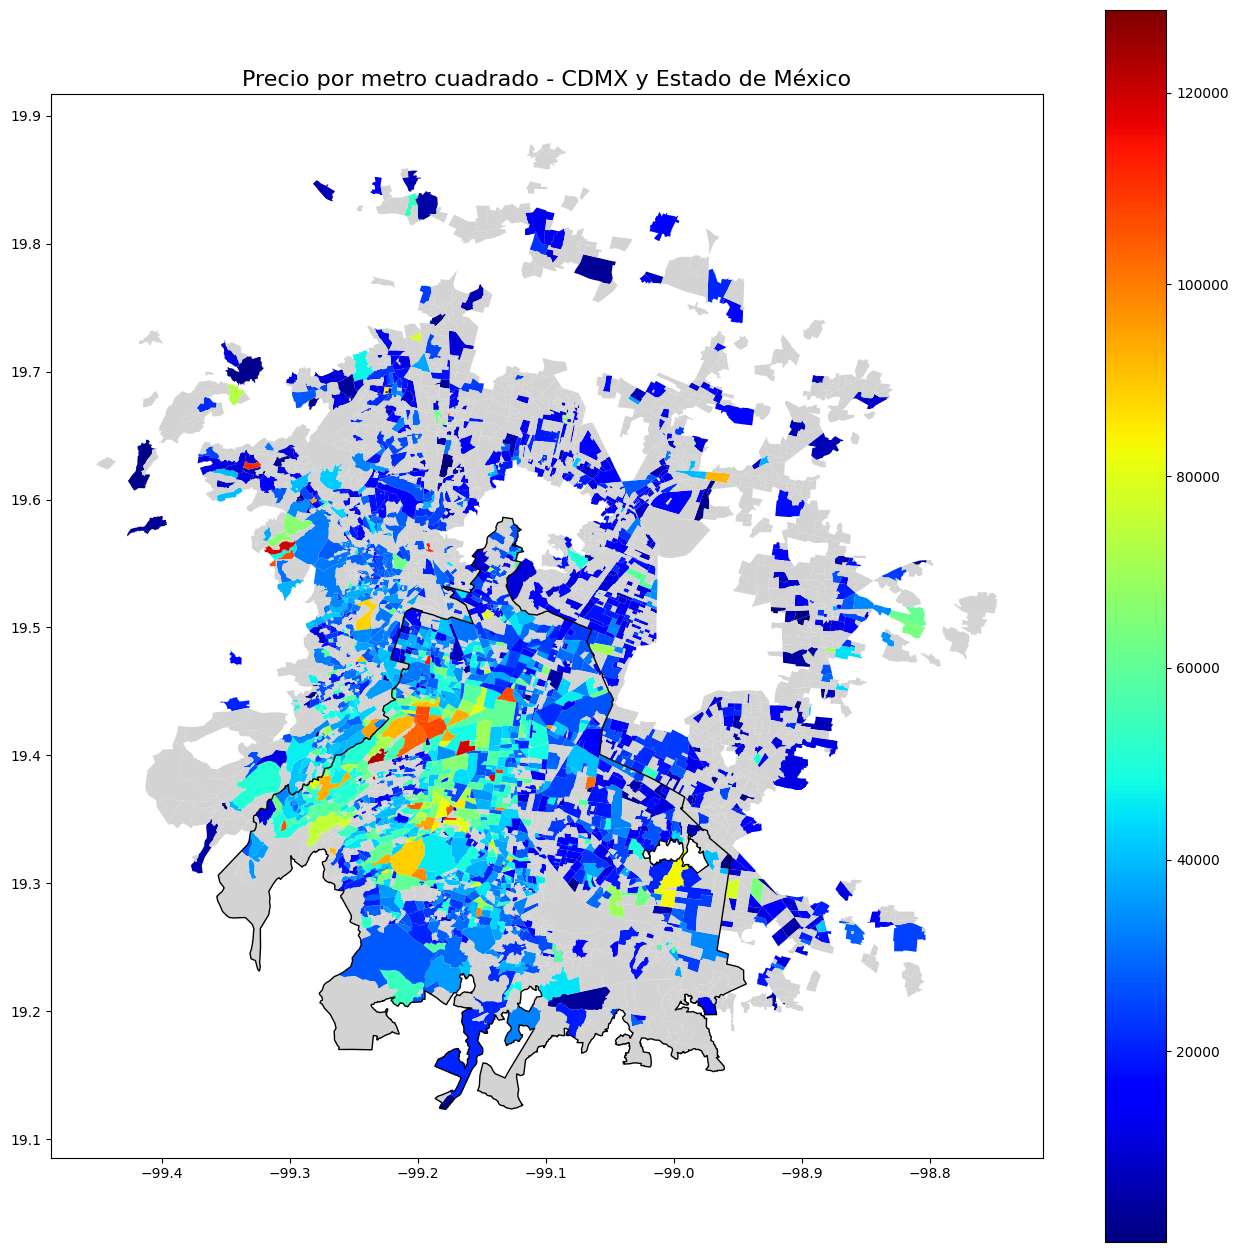

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt # Import wkt for converting string to geometry

# 1. Cargar el CSV final con los datos ya procesados
df_merged_final_fuzzy = pd.read_csv('/content/df_merged_final_fuzzy.csv')

# Convertir la columna 'geometry' de string WKT a objetos de geometría
# Esto es necesario ya que al guardar un GeoDataFrame a CSV, la geometría se convierte a texto.
df_merged_final_fuzzy['geometry'] = df_merged_final_fuzzy['geometry'].apply(wkt.loads)

# Convertir el DataFrame de pandas a un GeoDataFrame
df_map_final = gpd.GeoDataFrame(df_merged_final_fuzzy, geometry='geometry')

# 2. Definir una lista de municipios relevantes del Estado de México (reutilizado del código original)
edo_municipalities = [
    'ACOLMAN', 'ATENCO', 'ATIZAPÁN DE ZARAGOZA', 'CHALCO', 'CHIAUTLA',
    'CHICOLOAPAN', 'CHIMALHUACÁN', 'COACALCO DE BERRIOZÁBAL', 'CUAUTITLÁN',
    'CUAUTITLÁN IZCALLI', 'ECATEPEC DE MORELOS', 'HUEHUETOCA', 'HUIXQUILUCAN',
    'LA PAZ', 'NAUCALPAN DE JUÁREZ', 'NEZAHUALCÓYOTL', 'NICOLÁS ROMERO',
    'TECÁMAC', 'TEOLOYUCAN', 'TEOTIHUACÁN', 'TEPOTZOTLÁN', 'TEXCOCO',
    'TEZOYUCA', 'TLALNEPANTLA DE BAZ', 'TONANITLA', 'TULTEPEC', 'TULTITLÁN',
    'VALLE DE CHALCO SOLIDARIDAD', 'ZUMPANGO'
]

# 3. Filtrar el GeoDataFrame para incluir CDMX y los municipios específicos del Edo. de México
df_map_final_combined = df_map_final[
    (df_map_final['ST_NAME'] == 'DISTRITO FEDERAL') |
    ((df_map_final['ST_NAME'] == 'MEXICO') & (df_map_final['MUN_NAME'].isin(edo_municipalities)))
].copy()

# 4. Generación del mapa de calor combinado
fig, ax = plt.subplots(1, figsize=(16, 16))

# Dibujar el mapa de calor de precios para las áreas con datos
df_map_final_combined.dropna(subset=['precio_m2']).plot(column="precio_m2", cmap="jet", legend=True, ax=ax)
# Dibujar las áreas sin datos de precios en gris claro
df_map_final_combined[(df_map_final_combined['precio_m2'].isna())].plot(ax=ax, color='lightgrey')

# 5. Obtener el contorno de la CDMX para dibujarlo sobre el mapa combinado
# Filtrar solo las geometrías de la CDMX y unirlas
cdmx_outline = df_map_final_combined[df_map_final_combined["ST_NAME"] == "DISTRITO FEDERAL"].geometry.union_all()

# Dibujar el contorno de la CDMX en negro
gpd.GeoSeries([cdmx_outline]).boundary.plot(ax=ax, color='black', linewidth=1)

# Configurar título y guardar el mapa combinado
plt.title("Precio por metro cuadrado - CDMX y Estado de México", fontsize=16)
plt.savefig("precio_metro_cuadrado_cdmx_edomex_fuzzy.jpeg", dpi=1000, bbox_inches="tight")
plt.show()

In [ ]:
top_10_cdmx = df_map_final_cdmx_filtered.dropna(subset=['precio_m2']).sort_values(by='precio_m2', ascending=False).head(10)
print("Top 10 colonias más caras en CDMX:")
display(top_10_cdmx[['SETT_NAME', 'MUN_NAME', 'precio_m2']])

Top 10 colonias más caras en CDMX:


,SETT_NAME,MUN_NAME,precio_m2
1509,LOMAS ALTAS,MIGUEL HIDALGO,122773.675519
780,ROMA SUR,CUAUHTÉMOC,118550.490418
478,AMERICAS UNIDAS,BENITO JUÁREZ,118410.537596
97,LOMAS DE NUEVO MEXICO,ÁLVARO OBREGÓN,117647.058824
419,BARRIO SANTA APOLONIA,AZCAPOTZALCO,113487.872158
1197,BARRIO SAN LUCAS,IZTAPALAPA,113140.587378
501,BARRIO DE SANTA CATARINA,COYOACÁN,110225.673795
470,VILLA DE CORTES,BENITO JUÁREZ,109717.045025
1513,1A SECC DEL BOSQUE DE CHAPULTEPEC,MIGUEL HIDALGO,107347.000000
760,MORELOS,CUAUHTÉMOC,106628.258840
